In [106]:
from __future__ import annotations
from typing import Any
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
import math
from math import pi, sqrt

import scipy as sp
from scipy.integrate import simpson
import scipy.fft as fft

import itertools

d = 3 # Number of fock states to include

omega_q = 1 # GHz
omega_d = 1
anharmonicity = -0.4 # 400 MHz
alpha = 2*pi*anharmonicity

# Width of control pulse
tg = 6 # ns
t_pad = 0 # Add 0 strength sections to front and end of pulses (is this needed?)
N_t = 501
t_array = np.linspace(-t_pad, tg+t_pad, N_t)
dt = t_array[1] - t_array[0]

ad = qt.create(d)
a = qt.destroy(d)

def sigma_x(i, j):
    return qt.projection(d, i, j) + qt.projection(d, j, i)

def sigma_y(i, j):
    return 1j * (qt.projection(d, i, j) - qt.projection(d, j, i))

def H_R_func(t, args:dict[str, Any]):
    fI = args['fI'](t) if 'fI' in args else 0
    fQ = args['fQ'](t) if 'fI' in args else 0
    return (qt.qdiags([(omega_q-omega_d)*i + alpha/2 * i*(i-1) for i in range(d)])
            + fI/2 * sum([sqrt(i)*sigma_x(i-1, i) for i in range(1, d)])
            + fQ/2 * sum([sqrt(i)*sigma_y(i-1, i) for i in range(1, d)]))


# Control pulse for a square cutoff
def fI_window(t, tg):
    flag = (t >= 0) * (t < tg)
    return flag * 1/tg

# Control pulse for gaussian
def fI_gaussian(t, tg, sigma):
    flag = (t >= 0) * (t < tg)
    B = np.exp(-(tg**2) / (8*sigma**2))
    return flag * (np.exp(-(t-tg/2)**2 / (2*sigma**2)) - B) / (sqrt(2*pi)*sigma*math.erf(tg / (sqrt(8)*sigma)) - tg*B)

def fI_gaussian_fourier(omega, tg, sigma):
    B = np.exp(-(tg**2) / (8*sigma**2))
    c1 = 1 / (sqrt(2*pi)*sigma*math.erf(tg / (sqrt(8)*sigma)) - tg*B)
    return c1 * sqrt(2*pi)*sigma * np.exp(-(sigma*omega)**2 / 2) * sp.special.erf((tg/2 + 2j*sigma**2*omega) / (sqrt(2)*sigma)).real

# Reference: https://arxiv.org/pdf/2402.17757
def compute_fft(t_arr, y_arr):
    n_y = len(y_arr)
    dt = t_arr[1] - t_arr[0]
    #tg = t_arr[-1]

    # Add 0's to end of pulse
    n_z = 20 * n_y
    #tz = n_z * dt
    #t_arr_tot = np.concatenate([t_arr, np.linspace(tg+dt, tg+tz, n_z)])
    y_arr_tot = np.concatenate([y_arr, np.zeros(n_z)])
    n_tot = len(y_arr_tot)

    #y_fft = fft.fftshift(fft.fft(fft.ifftshift(y_arr))) * dt
    y_fft = fft.fftshift(fft.fft(y_arr_tot)) * dt
    f_arr = fft.fftshift(fft.fftfreq(n_tot, dt))

    return f_arr, np.abs(y_fft)

def is_dm(obj:qt.Qobj):
    """Returns True if the object is a density matrix."""
    return obj.isoper and obj.isherm and np.abs(obj.tr() - 1) <= 1e-10

def L(state:qt.Qobj):
    """Returns 'Leakage' of a given state, defined as trace of projecting into the non-computational subspace."""
    if is_dm(state):
        rho = state
    else:
        rho = qt.ket2dm(state)

    return 1 - np.abs(rho[0,0] + rho[1,1])

def generate_array_from(f, *ranges):
    """Create an array with size equal to (len(ranges[0]), len(ranges[1]), len(ranges[2])...) and fills it with evaluating f on all enumerated range values."""
    enumed_ranges = [list(enumerate(r)) for r in ranges]
    result = np.zeros([len(r) for r in ranges])

    for items in itertools.product(*enumed_ranges):
        indices = [item[0] for item in items]
        result[*indices] = f(*items)
    
    return result

In [107]:
psi0 = qt.basis(d, 0)

H_R = qt.QobjEvo(H_R_func, args={'fI': lambda t: pi*fI_window(t, tg), 'fQ': lambda t: 0})
result = qt.sesolve(H_R, psi0, t_array)
display(result.final_state)
print(f"Leakage = {L(result.final_state):.4f}")

Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.0242275 +0.09885014j]
 [-0.15655781-0.97186113j]
 [-0.0373423 -0.13864639j]]

Leakage = 0.0206


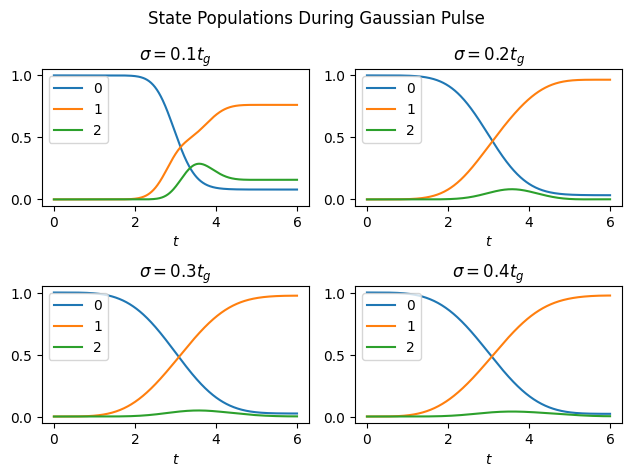

In [108]:
def simulate_H(H_func, fI, fQ, psi0, t_arr):
    H = qt.QobjEvo(H_func, args={'fI': fI, 'fQ': fQ})
    result = qt.sesolve(H, psi0=psi0, tlist=t_arr, e_ops=[qt.projection(d,i,i) for i in range(d)], options={'store_final_state': True})
    return result

sigma_array = np.linspace(0.1, 0.4, 4) * tg
leakage_array = np.zeros([len(sigma_array)])
psi0 = qt.basis(d, 0)

A = pi
f_lim = 2 # GHz

fig1, axs1 = plt.subplots(2, 2)
for i, sigma in enumerate(sigma_array):
    result = simulate_H(H_R_func, fI=lambda t: A*fI_gaussian(t, tg, sigma), fQ=lambda t: 0, psi0=psi0, t_arr=t_array)
    leakage_array[i] = L(result.final_state)

    ax = axs1[i//2, i%2]
    for j in range(d):
        ax.plot(t_array, result.e_data[j])
    ax.set_xlabel("$t$")
    ax.legend(list(range(d)), loc='upper left')
    ax.set_title(fr"$\sigma={sigma/tg:.1f}t_g$")

fig1.suptitle("State Populations During Gaussian Pulse")
fig1.tight_layout(pad=1)
fig1.savefig("State Populations During Gaussian.png")

Avoid frequency 0.4000


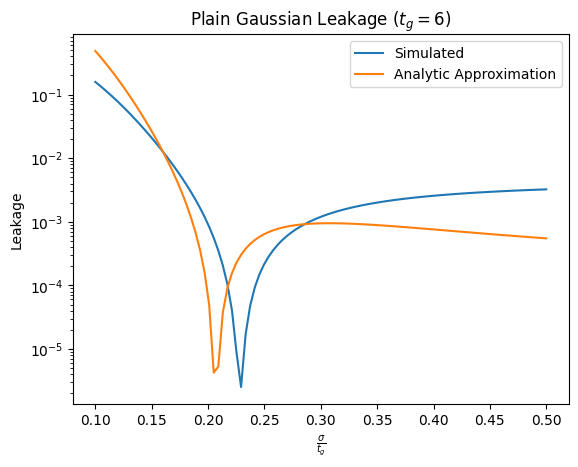

In [109]:
H_R_gaussian = qt.QobjEvo(H_R_func, args={'fI': lambda t: 0, 'fQ': lambda t: 0})
f_bad = np.abs(H_R_gaussian(0)[2,2]) / (2*pi)
print(f"Avoid frequency {f_bad:.4f}")

sigma_array2 = np.linspace(0.1, 0.5, 100) * tg
leakage_array2 = np.zeros(len(sigma_array2))
fourier_strength_array = np.zeros(len(sigma_array2))

# Plot error between DFT and analytical
for i, sigma in enumerate(sigma_array2):
    result = simulate_H(H_R_func, fI=lambda t: A*fI_gaussian(t, tg, sigma), fQ=lambda t: 0, psi0=psi0, t_arr=t_array)
    leakage_array2[i] = L(result.final_state)

    gaussian_array = A*fI_gaussian(t_array, tg, sigma)
    f_arr, y_fft = compute_fft(t_array, gaussian_array)
    omega_arr = 2*pi*f_arr

    # B = np.exp(-(tg**2) / (8*sigma**2))
    # c1 = 1 / (sqrt(2*pi)*sigma*math.erf(tg / (sqrt(8)*sigma)) - tg*B)
    # z = (tg/2 + 1j*sigma**2*omega_arr) / (sqrt(2)*sigma)
    # x_gauss = sqrt(2*pi)*sigma * np.exp(-(sigma*omega_arr)**2 / 2) * sp.special.erf(z).real
    # x_shift = B * tg * np.sinc((omega_arr/(2*pi))*tg)
    # z_fft = A * c1 * (x_gauss - x_shift)# * np.exp(-1j * omega_arr * tg/2)
    # z_fft = np.abs(z_fft)

    i_bad_approx = np.argmin(np.abs(f_arr - f_bad))
    fourier_strength_array[i] = y_fft[i_bad_approx]

    # Plot error between DFT and analytical
    # plt.figure()
    # plt.semilogy(f_arr, y_fft)
    # #plt.semilogy(f_arr, z_fft)
    # plt.axvline(f_bad, color='k', linestyle='--')
    # plt.xlim(-f_lim, f_lim)
    # plt.ylim(1e-5, 10)
    # #plt.legend(["DFT", "Analytic"])
    # plt.show()

#print(fourier_strength_array)

plt.figure()
plt.semilogy(sigma_array2/tg, leakage_array2)
plt.semilogy(sigma_array2/tg, (sqrt(2)/2)**2 * fourier_strength_array**2)
plt.xlabel(r"$\frac{\sigma}{t_g}$")
plt.ylabel("Leakage")
plt.legend(["Simulated", "Analytic Approximation"])
plt.title(fr"Plain Gaussian Leakage $(t_g={tg})$")
plt.savefig("Simulated vs Analytic Leakage.png")
plt.show()

In [110]:
display(H_R_gaussian(0))

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 0.          0.          0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.         -2.51327412]]

Plot leakage for different gate times for plain Gaussian

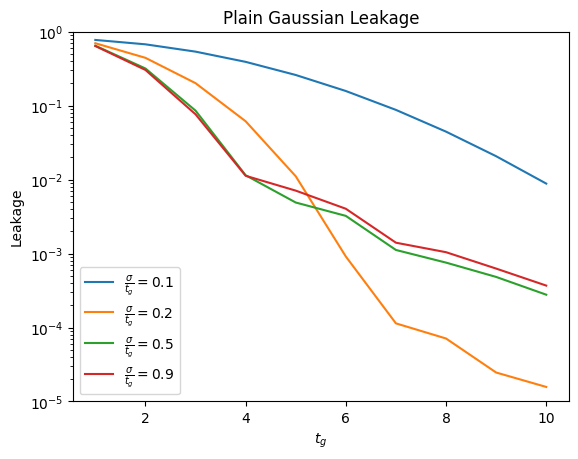

In [111]:
tg_array = np.linspace(1, 10, 10) # ns
sigma_array = np.array([0.1, 0.2, 0.5, 0.9])

leakage_array2 = np.zeros([len(tg_array), len(sigma_array)])

def get_gauss_leakage2(_tg, _sigma):
    _, tg = _tg
    _, sigma_scalar = _sigma

    sigma = sigma_scalar * tg
    t_array = np.linspace(-t_pad, tg+t_pad, 100)
    H_R_gaussian = qt.QobjEvo(H_R_func, args={'fI': lambda t: pi*fI_gaussian(t, tg, sigma), 'fQ': lambda t: 0})
    result = qt.sesolve(H_R_gaussian, psi0, t_array)
    return L(result.final_state)

leakage_array2 = generate_array_from(get_gauss_leakage2, tg_array, sigma_array)

plt.semilogy(tg_array, leakage_array2)
plt.xlabel(r"$t_g$")
plt.ylabel("Leakage")
plt.ylim(1e-5, 1)
plt.title("Plain Gaussian Leakage")
plt.legend([fr"$\frac{{\sigma}}{{t_g}}={s}$" for s in sigma_array])
plt.show()